### FEATURE ENGINEERING PIPELINE – TTC Delay Prediction Project
<div style="font-size: 12.5px;">
  <h4>PURPOSE:</h4>
  <p>
    This script transforms raw and cleaned datasets into a machine learning-ready dataset.
    It combines multiple data sources and generates features required for predicting bus delay risk.
  </p>

  <h4>INPUT DATA SOURCES:</h4>
  <ul>
    <li>TTC Bus Delay historical data (2022–2025)</li>
    <li>GTFS data (routes, stops, schedules, geometry)</li>
    <li>Weather data (temperature, precipitation, conditions)</li>
  </ul>

  <h4>CORE PURPOSE:</h4>
  <ul>
    <li>Merge all datasets into a single unified training table</li>
    <li>Create meaningful features from time, route, and weather</li>
    <li>Prepare structured dataset for machine learning model training</li>
  </ul>

  <h4>FEATURE ENGINEERING INCLUDES:</h4>
  <ul>
    <li>Route-level merging using GTFS information</li>
    <li>Weather feature integration (temperature, precipitation, etc.)</li>
    <li>Time-based features (hour, day of week, etc.)</li>
  </ul>

  <h4>OUTPUT:</h4>
  <p>
    Final ML-ready dataset stored in:
    <code>data/output/final_training_data.csv</code>
  </p>
</div>

In [36]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import re
import pickle
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

#### CONFIG

In [3]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = DATA_DIR / "output"
CACHE_DIR = DATA_DIR / "cache"

TTC_DIR = RAW_DIR / "ttc_bus"
WEATHER_DIR = RAW_DIR / "weather"
GTFS_DIR = RAW_DIR / "ttc_gtfs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

#### LOAD DATA

In [4]:
# TTC Bus Delay Records 
df_2022 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2022.xlsx")
df_2023 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2023.xlsx")
df_2024 = pd.read_excel(TTC_DIR / "ttc-bus-delay-data-2024.xlsx")
df_2025 = pd.read_csv(TTC_DIR / "ttc-bus-delay-data-since-2025.csv")

# Historical Weather data
weather_df = pd.read_csv(WEATHER_DIR / "toronto_weather_2022_2025.csv")

# GTFS data
routes_df = pd.read_csv(GTFS_DIR / "routes.txt")
trips_df = pd.read_csv(GTFS_DIR / "trips.txt")
stops_df = pd.read_csv(GTFS_DIR / "stops.txt")
stop_times_df = pd.read_csv(GTFS_DIR / "stop_times.txt")

C:\Users\amras\AppData\Local\Temp\ipykernel_56396\34326791.py:8: DtypeWarning: Columns (11,13,15,17,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(WEATHER_DIR / "toronto_weather_2022_2025.csv")


In [5]:
# print("\nWeather")
# print(weather_df.shape)
# print(weather_df.columns.tolist())
# print("\nRoutes")
# print(routes_df.shape)
# print(routes_df.columns.tolist())
# print("\nTrips")
# print(trips_df.shape)
# print(trips_df.columns.tolist())
# print("\nStops")
# print(stops_df.shape)
# print(stops_df.columns.tolist())
# print("\nStop Times")
# print(stop_times_df.shape)
# print(stop_times_df.columns.tolist())

##### STANDARDIZE 2025 SCHEMA TO MATCH 2022-2024

In [6]:
# 2025 files have different column names than 2022-2024
# This step converts 2025 columns to match the format
# Map: Line→Route, Station→Location, Code→Incident, Bound→Direction
def standardize_schema(bus_df):
    bus_df = bus_df.copy()
    
    # Extract route number from "Line" column
    if "Line" in bus_df.columns:
        bus_df["Route"] = bus_df["Line"].astype(str).str.extract(r"(\d+)")[0]

    # Rename columns to match 2022-2024 schema
    bus_df = bus_df.rename(columns={"Station": "Location", "Code": "Incident", "Bound": "Direction"})
    return bus_df

# Standardize 2025 and combine all years
bus_frames = []
df_2025 = standardize_schema(df_2025)
# append to bus_frame
bus_frames.append(df_2025)
bus_frames.append(df_2024)
bus_frames.append(df_2023)
bus_frames.append(df_2022)
bus_df = pd.concat(bus_frames, ignore_index=True)

print(bus_df.columns.tolist())

['_id', 'Date', 'Line', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction', 'Vehicle', 'Route', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']


#### DATA PROCESSING: CLEAN BUS DELAY DATA

In [7]:
# Cleaning: standardize columns, parse dates, validate numeric fields, normalize text, map incidents
def clean_bus_delays(bus_df):
    bus_df = bus_df.copy()
    # Standardize column names to lowercase with underscores
    bus_df.columns = (bus_df.columns.str.strip().str.replace(" ", "_").str.lower())
    
    # Drop unnecessary columns
    # keep ['Date', 'Route', 'Time', 'Day', 'Location', 'Incident', 'Min Delay', 'Min Gap', 'Direction']
    drop_cols = ["line", "station", "_id", "vehicle", "bound", "code"]
    bus_df = bus_df.drop(columns=[c for c in drop_cols if c in bus_df.columns])

    # ---- Parse date/time ----
    bus_df["date"] = pd.to_datetime(bus_df["date"], errors="coerce")
    # combine date and time into one datetime column
    # Bus delay depends heavily on exact timestamp
    bus_df["datetime"] = pd.to_datetime(bus_df["date"].dt.strftime("%Y-%m-%d") + " " + bus_df["time"].astype(str), errors="coerce")
    # drop rows where date failed to parse entirely
    bus_df = bus_df.dropna(subset=["date"])

    # ---- Route Validation ----
    # Must be numeric and valid TTC route
    bus_df["route"] = pd.to_numeric(bus_df["route"], errors="coerce")
    bus_df = bus_df.dropna(subset=["route"])
    bus_df["route"] = bus_df["route"].astype(int)

    # ---- Delay/gap validation ----
    # Convert to numeric, drop invalid
    bus_df["min_delay"] = pd.to_numeric(bus_df["min_delay"], errors="coerce")
    bus_df["min_gap"] = pd.to_numeric(bus_df["min_gap"], errors="coerce")
    bus_df = bus_df.dropna(subset=["min_delay", "min_gap"])

    # Remove extreme outliers (errors in data) 
    # 120 min delay = long recovery, acceptable threshold
    # 240 min gap = very long headway, acceptable threshold
    bus_df = bus_df[(bus_df["min_delay"] >= 0) & (bus_df["min_delay"] < 120)]
    bus_df = bus_df[(bus_df["min_gap"] >= 0) & (bus_df["min_gap"] < 240)]

    # ---- Direction Validation ----
    # Standardize text, keep missing as "Unknown"
    valid_directions = ["N", "S", "E", "W", "UNKNOWN"]
    bus_df["direction"] = np.where(bus_df["direction"].isin(valid_directions), bus_df["direction"], "UNKNOWN")

    # Clean text formatting 
    bus_df["incident"] = bus_df["incident"].astype(str).str.strip()
    bus_df["location"] = bus_df["location"].astype(str).str.strip()
    bus_df["day"] = bus_df["day"].astype(str).str.strip().str.title()

    # ---- Incident Mapping ----
    # TTC incident descriptions vary across years
    # To ensure consistency for machine learning, all incidents are mapped into a common set of operational categories
    bus_df["incident_raw"] = bus_df["incident"].astype(str).str.strip().str.upper()

    incident_mapping = {
        # Mechanical / Vehicle
        "MECHANICAL": "Mechanical / Vehicle Failure",
        "MFO": "Mechanical / Vehicle Failure",     
        "EFO": "Mechanical / Vehicle Failure",
        "EFB": "Mechanical / Vehicle Failure",
        "EFD": "Mechanical / Vehicle Failure",
        "EFDB": "Mechanical / Vehicle Failure",
        "EFHV": "Mechanical / Vehicle Failure",
        "EFHVA": "Mechanical / Vehicle Failure",
        "EFLV": "Mechanical / Vehicle Failure",
        "EFP": "Mechanical / Vehicle Failure",
        "EFT": "Mechanical / Vehicle Failure",
        "EFTB": "Mechanical / Vehicle Failure",
        # Operations / Scheduling
        "EFCAN": "Operations / Scheduling",
        "GENERAL DELAY": "Operations / Scheduling",
        "MFUS": "Operations / Scheduling",
        "MFGD": "Operations / Scheduling",
        "TFLF": "Operations / Scheduling",
        "TFLL": "Operations / Scheduling",
        "OPERATIONS - OPERATOR": "Operations / Scheduling",
        "UTILIZED OFF ROUTE": "Diversion / Routing", # Off-route diversion
        # Security / Police
        "SECURITY": "Security / Police",
        "SFAE": "Security / Police",
        "SFAP": "Security / Police",
        "SFBT": "Security / Police",
        "SFDP": "Security / Police",
        "SFO": "Security / Police",
        "SFPOL": "Security / Police",
        "SFSA": "Security / Police",
        "SFSP": "Security / Police",
        # Collision
        "COLLISION - TTC": "Collision / Accident",
        "MFPI": "Collision / Accident",
        "PFPD": "Collision / Accident",
        "TFPD": "Collision / Accident",
        "TFPI": "Collision / Accident",
        # Emergency
        "MFS": "Emergency Services",
        "EMERGENCY SERVICES": "Emergency Services",
        # Road / Infrastructure
        "EFRA": "Road / Infrastructure Issue",
        "TFO": "Road / Infrastructure Issue",
        "MFPR": "Investigation / Held",
        "ROAD BLOCKED - NON-TTC COLLISION": "Road / Infrastructure Issue",
        # Diversion
        "DIVERSION": "Diversion / Routing",
        "MFDV": "Diversion / Routing",
        # Cleaning
        "MFCN": "Cleaning / Sanitation",
        "MFSAN": "Cleaning / Sanitation",
        "CLEANING - UNSANITARY": "Cleaning / Sanitation",
        "CLEANING - DISINFECTION": "Cleaning / Sanitation",
        # Medical / Passenger
        "MFUI": "Medical / Passenger Health",
        "MFUIR": "Medical / Passenger Health",
        "TFOI": "Medical / Passenger Health",
        # Vision
        "MFVIS": "Vision / Visibility",
        "VISION": "Vision / Visibility",
        # Investigation
        "INVESTIGATION": "Investigation / Held",
        "HELD BY": "Investigation / Held",
        "MFPR": "Investigation / Held",
        "SFPOL": "Investigation / Held",
        # Weather
        "MFWEA": "Weather Related",
        # Staffing
        "TFCNO": "Staffing / Operator Issue",
        "MFTO": "Staffing / Operator Issue",
        "MFESA": "Staffing / Operator Issue",
        "LATE ENTERING SERVICE": "Staffing / Operator Issue",
        # Fare/Admin
        "MFFD": "Fare / Administrative",
        # Miscellaneous Facilities/Station Hazards
        "MFSH": "Road / Infrastructure Issue"
    }

    # Create standardized incident category
    bus_df["incident_category"] = (bus_df["incident_raw"].map(incident_mapping).fillna("Other"))

    # Drop duplicate rows
    bus_df = bus_df.drop_duplicates()
    return bus_df.reset_index(drop=True)

bus_df_clean = clean_bus_delays(bus_df)

<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
<p><b>Note:</b><br>
Zero-delay records (min_delay = 0) were analyzed and retained in the dataset. Although they do not represent active delay events, they are important for modeling normal operational conditions of the transit system. Keeping these records ensures that the machine learning model learns the difference between normal service and delayed operations, reducing bias toward overestimating delays and improving real-world prediction accuracy.</p></div>

#### LOCATION NORMALIZATION

In [8]:
def normalize_location(text):
    if not isinstance(text, str):
        return text
    text = text.upper().strip()
    text = re.sub(r'\s*/\s*',   ' AND ', text)
    text = re.sub(r'\s*&\s*',   ' AND ', text)
    text = re.sub(r'\s+AT\s+',  ' AND ', text)
    text = re.sub(r'\s+@\s+',   ' AND ', text)
    text = re.sub(r'\s+AT\s*$', '', text)
    text = re.sub(r'(\s+AND\s+)+', ' AND ', text)
    text = re.sub(r'\s+AND\s*$', '', text)
    replacements = {
        r'\bAVE?\b': 'AVE', r'\bBLVD\b': 'BLVD',
        r'\bCRT?\b': 'CRT', r'\bDR\b':   'DR',
        r'\bPKWY\b': 'PKWY',r'\bRD\b':   'RD',
        r'\bST\b':   'ST',  r'\bTERR?\b':'TER',
        r'\bNORTH\b':'N',   r'\bSOUTH\b':'S',
        r'\bEAST\b': 'E',   r'\bWEST\b': 'W',
    }
    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

bus_df_clean["location_normalized"] = bus_df_clean["location"].apply(normalize_location)
print(f"Unique raw locations:        {bus_df_clean['location'].nunique():,}")
print(f"Unique normalized locations: {bus_df_clean['location_normalized'].nunique():,}")

# LOCATION LOOKUP TABLE — for reference
location_lookup = (bus_df_clean.groupby("location_normalized").agg(location_raw = ("location","first"), 
                  total_incidents = ("location_normalized",  "count"),).reset_index()
                  .sort_values("total_incidents", ascending=False).reset_index(drop=True))
location_lookup["location_id"] = location_lookup.index + 1
location_lookup = location_lookup[["location_id", "location_normalized", "location_raw", "total_incidents"]]
location_lookup.to_csv(OUTPUT_DIR / "location_lookup.csv", index=False)

# JOIN location_id BACK TO MAIN DATASET
id_map = location_lookup.set_index("location_normalized")["location_id"].to_dict()
bus_df_clean["location_id"] = (bus_df_clean["location_normalized"].fillna("UNKNOWN").map(id_map))
print(f"location_id coverage: {bus_df_clean['location_id'].notna().mean():.1%}")

Unique raw locations:        27,721
Unique normalized locations: 26,904
location_id coverage: 100.0%


##### FILTER TO VALID GTFS ROUTES

In [9]:
# Route identifiers were validated against official TTC GTFS routes
# Ensure route IDs are strings for consistent matching
# Records with unknown route numbers are removed
routes_df["route_id"] = routes_df["route_id"].astype(str)
routes_df["route_short_name"] = routes_df["route_short_name"].astype(str)
valid_routes = set(routes_df["route_short_name"])

# Count invalid routes before filtering
before_rows = len(bus_df_clean)
bus_df_clean = bus_df_clean[bus_df_clean["route"] != 0] # Remove route 0 (invalid)
# Keep only routes that exist in GTFS
bus_df_clean = bus_df_clean[bus_df_clean["route"].astype(str).isin(valid_routes)]

print(f"Routes removed: {before_rows - len(bus_df_clean):,}")
print(f"Remaining rows: {len(bus_df_clean):,}\n")

Routes removed: 4,275
Remaining rows: 244,771



<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
<p><b>Note:</b><br>
Approximately 1.7% of records contained route values that could not be matched to any valid TTC route. These records were removed to ensure consistency between historical delay data and GTFS-derived route features used in the prediction model.</p></div>

##### SELECT TOP 50 ROUTES BY IMPACT

In [10]:
# Calculate route statistics
route_stats = bus_df_clean.groupby("route").agg({"min_delay": ["sum", "mean", "count"]}).reset_index()
route_stats.columns = ["route", "total_delay", "avg_delay", "incident_count"]

# Priority routes (high-demand TTC routes)
priority_routes = ["7", "24", "25", "29", "35", "39", "60", "100", "165", "924", "925", "929"]

# Add highest-impact routes to reach 50 total
remaining_routes = route_stats[~route_stats["route"].astype(str).isin(priority_routes)] # Remove priority routes from ranking pool
top_remaining = remaining_routes.sort_values(by="total_delay", ascending=False).head(50 - len(priority_routes))
final_routes = priority_routes + top_remaining["route"].astype(str).tolist()

# Filter bus data to only selected routes
bus_df_clean = bus_df_clean[bus_df_clean["route"].astype(str).isin(final_routes)].copy()

print(f"Selected {len(final_routes)} routes:")
print(sorted([int(r) for r in final_routes]))

Selected 50 routes:
[7, 11, 12, 24, 25, 29, 32, 34, 35, 36, 37, 38, 39, 40, 41, 43, 45, 47, 52, 53, 54, 59, 60, 63, 68, 72, 73, 79, 84, 85, 86, 89, 94, 95, 96, 97, 100, 102, 108, 110, 116, 123, 129, 133, 165, 924, 925, 929, 939, 960]


#### FEATURE ENGINEERING: BUS DELAY DATA - TIME-BASED FEATURES

In [11]:
# Time-based features
bus_df_clean["hour"] = bus_df_clean["datetime"].dt.hour
bus_df_clean["month"] = bus_df_clean["datetime"].dt.month
bus_df_clean["year"] = bus_df_clean["datetime"].dt.year
bus_df_clean["is_weekend"] = bus_df_clean["day"].isin(["Saturday", "Sunday"]).astype(int)
bus_df_clean["is_rush_hour"] = bus_df_clean["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
bus_df_clean["day_of_week"] = bus_df_clean["datetime"].dt.dayofweek
bus_df_clean["season"] = ((bus_df_clean["month"] % 12 + 3) // 3) # Season: 1=Winter 2=Spring 3=Summer 4=Fall

In [12]:
print("Bus Delay Cleaning Summary")
print(f"Rows: {bus_df_clean.shape[0]}")
print(f"Missing location: {bus_df_clean['location'].isna().sum()}")
print(f"Missing incident: {bus_df_clean['incident'].isna().sum()}")
print(f"Unique routes: {bus_df_clean['route'].nunique()}")
print(f"Route range: {bus_df_clean['route'].min()} - {bus_df_clean['route'].max()}")
print(f"\nIncident value counts:\n{bus_df_clean['incident_category'].value_counts()}")

Bus Delay Cleaning Summary
Rows: 152088
Missing location: 0
Missing incident: 0
Unique routes: 50
Route range: 7 - 960

Incident value counts:
incident_category
Mechanical / Vehicle Failure    52563
Operations / Scheduling         33575
Diversion / Routing             11389
Collision / Accident            10400
Security / Police               10193
Road / Infrastructure Issue      7526
Staffing / Operator Issue        5962
Cleaning / Sanitation            5250
Emergency Services               5037
Vision / Visibility              3530
Medical / Passenger Health       3163
Investigation / Held             2392
Weather Related                   662
Other                             445
Fare / Administrative               1
Name: count, dtype: int64


#### DATA PROCESSING: CLEAN WEATHER DATA

In [13]:
# Parse weather data, fill missing values, aggregate to hourly
def clean_weather(weather_df):
    weather_df = weather_df.copy()
    # Standardize column names
    weather_df.columns = weather_df.columns.str.lower().str.strip()

    # Parse datetime
    weather_df["datetime"] = pd.to_datetime(weather_df["date/time (lst)"], errors="coerce")
    weather_df = weather_df.dropna(subset=["datetime"]) # Drop invalid timestamps

    # Keep relevant columns
    cols = ["datetime", "temp (°c)", "rel hum (%)", "precip. amount (mm)", "wind spd (km/h)", "visibility (km)"]
    weather_df = weather_df[[c for c in cols if c in weather_df.columns]]

    # Convert to numeric
    num_cols = [c for c in weather_df.columns if c != "datetime"]
    for col in num_cols:
        weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

    # Forward fill missing values
    weather_df[num_cols] = weather_df[num_cols].ffill()

    # Aggregate to hourly (take median for stability)
    weather_df["hour_dt"] = weather_df["datetime"].dt.floor("h")
    weather_hourly = weather_df.groupby("hour_dt")[num_cols].median().reset_index()
    weather_hourly.columns = ["hour_dt", "temp_celsius", "humidity_pct", 
                              "precipitation_mm", "wind_speed_kmh", "visibility_km"]

    return weather_hourly

weather_clean = clean_weather(weather_df)
print(f"Weather data cleaned: {len(weather_clean):,}")

Weather data cleaned: 35,064


In [18]:
print("Weather validation check")
print("Missing values:")
print(weather_clean.isnull().sum())

Weather validation check
Missing values:
hour_dt             0
temp_celsius        0
humidity_pct        0
precipitation_mm    0
wind_speed_kmh      0
visibility_km       0
dtype: int64


#### MERGE WEATHER INTO BUS DATA

In [15]:
# Create hourly key for joining
bus_df_clean["hour_dt"] = bus_df_clean["datetime"].dt.floor("h")
# Merge weather
bus_df_clean = bus_df_clean.merge(weather_clean, on="hour_dt", how="left")

# Fill missing weather with medians (safety)
bus_df_clean["temp_celsius"] = bus_df_clean["temp_celsius"].fillna(bus_df_clean["temp_celsius"].median())
bus_df_clean["humidity_pct"] = bus_df_clean["humidity_pct"].fillna(bus_df_clean["humidity_pct"].median())
bus_df_clean["precipitation_mm"] = bus_df_clean["precipitation_mm"].fillna(0)
bus_df_clean["wind_speed_kmh"] = bus_df_clean["wind_speed_kmh"].fillna(bus_df_clean["wind_speed_kmh"].median())
bus_df_clean["visibility_km"] = bus_df_clean["visibility_km"].fillna(bus_df_clean["visibility_km"].median())

#### FEATURE ENGINEERING: BUS DELAY DATA - CREATE DELAY TARGETS

In [19]:
# Route-level statistics
print("ROUTE-LEVEL DELAY THRESHOLD EXPLORATION")
summary = bus_df_clean.groupby("route")["min_delay"].agg(Count="count", Median="median", Mean="mean",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    P75=lambda x: x.quantile(0.75),
    P80=lambda x: x.quantile(0.80),
    P85=lambda x: x.quantile(0.85),
    P90=lambda x: x.quantile(0.90),
    Max="max")
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary["Upper_Fence"] = summary["Q3"] + 1.5 * summary["IQR"]

# Class balance per threshold
for p in [0.75, 0.80, 0.85, 0.90]:
    threshold = bus_df_clean.groupby("route")["min_delay"].transform(
        lambda x: x.quantile(p))
    rate = (bus_df_clean["min_delay"] > threshold).mean()
    print(f"P{int(p*100)} rate: {rate:.1%}")

iqr_rate = (bus_df_clean["min_delay"] > summary.loc[bus_df_clean["route"], "Upper_Fence"].values).mean()
print(f"IQR rate: {iqr_rate:.1%}")

# Global medians
print("\nMedian thresholds across routes")
print(summary[["P75","P80","P85","P90","Upper_Fence"]].median())

ROUTE-LEVEL DELAY THRESHOLD EXPLORATION
P75 rate: 18.2%
P80 rate: 15.1%
P85 rate: 11.2%
P90 rate: 7.7%
IQR rate: 6.9%

Median thresholds across routes
P75            15.0
P80            17.5
P85            20.0
P90            20.0
Upper_Fence    25.5
dtype: float64


<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">

<b>MAJOR DELAY TARGET (is_major_delay)</b><br>
Route-Specific 80th Percentile Method

<b>DEFINITION</b><br>
An incident is classified as a major delay when its observed Min Delay exceeds the 80th percentile of Min Delay for that route.

<b>METHODOLOGICAL RATIONALE</b><br>
Delay severity varies significantly across routes due to differences in service frequency and operating conditions. A route-specific threshold is therefore used instead of a fixed cutoff (e.g. 20 minutes).

Several candidate thresholds (P75, P80, P85, P90, and IQR-based outliers) were evaluated during exploratory analysis. These showed a trade-off between class balance and operational strictness:
• P75 (18.2%) → too permissive, includes routine delays  
• P80 (15.1%) → balanced representation of severe delays  
• P85 (11.2%) → higher purity but reduced sample size  
• P90 (7.7%) → overly restrictive, captures only extreme cases  

<b>P80 was selected as the optimal trade-off between:</b>
(1) maintaining sufficient positive class balance for machine learning (15.1%)  
(2) capturing operationally significant delays validated through earlier gapping analysis  
(3) preserving route-level comparability without restricting the target to rare outliers  

Importantly, P80 and P85 identify broadly similar high-risk routes, but P80 retains higher coverage of meaningful delay events.

This approach follows guidance from TCRP Report 88 (TRB, 2003), which recommends distribution-based and route-level performance measures for transit systems rather than fixed absolute thresholds.<br>
Transportation Research Board (2003). <i>TCRP Report 88: A Guidebook for Developing a Transit Performance-Measurement System</i>.
https://trb.org/publications/tcrp/tcrp_rpt_88.pdf

<b>INTERPRETATION NOTE</b><br>
This dataset contains incident-based disruption records rather than continuous vehicle trajectories. Therefore, “major delay” is defined relative to each route’s historical delay distribution rather than a fixed network-wide threshold.
</div>

In [20]:
# TARGET 1 — MAJOR DELAY
# Route-specific 80th percentile
# Sort before any calculations
bus_df_clean = bus_df_clean.sort_values(["route", "direction", "datetime"]).reset_index(drop=True)

route_p80_delay = (bus_df_clean.groupby("route")["min_delay"].transform(lambda x: x.quantile(0.80)))
bus_df_clean["is_major_delay"] = (bus_df_clean["min_delay"] > route_p80_delay).astype(int)

# Validation
major_count = bus_df_clean["is_major_delay"].sum()
major_rate = bus_df_clean["is_major_delay"].mean()
total = len(bus_df_clean)

print(f"Major delays  : {major_count:,} of {total:,}")
print(f"Major delay rate : {major_rate:.1%}")
print(f"Normal rate      : {1-major_rate:.1%}")

Major delays  : 22,957 of 152,088
Major delay rate : 15.1%
Normal rate      : 84.9%


##### CREATE SERVICE IRREGULARITY FEATURES (GAPPING/BUNCHING)

In [21]:
# Does Min Gap vary a lot within the same route?
gap_stats = bus_df_clean.groupby("route")["min_gap"].agg(["count", "mean", "std"])
gap_stats = gap_stats[gap_stats["count"] >= 20]
gap_stats["coef_of_variation"] = gap_stats["std"] / gap_stats["mean"]
print("Median coefficient of variation across routes:", round(gap_stats["coef_of_variation"].median(), 2))
 
# How strongly is Min Gap correlated with Min Delay?
overall_corr = bus_df_clean["min_delay"].corr(bus_df_clean["min_gap"])
print("Correlation between Min Delay and Min Gap:", round(overall_corr, 3))
 
# What is the typical Min Gap / Min Delay ratio?
ratio_df = bus_df_clean[bus_df_clean["min_delay"] > 0].copy()
ratio_df["ratio"] = ratio_df["min_gap"] / ratio_df["min_delay"]
print("Median Min Gap / Min Delay ratio:", round(ratio_df["ratio"].median(), 2))

# Best-fit relationship: Min Gap = slope * Min Delay + intercept
slope, intercept = np.polyfit(bus_df_clean["min_delay"], bus_df_clean["min_gap"], 1)
print(f"Best fit: Min Gap = {slope:.2f} * Min Delay + {intercept:.2f}")

Median coefficient of variation across routes: 0.6
Correlation between Min Delay and Min Gap: 0.9
Median Min Gap / Min Delay ratio: 2.0
Best fit: Min Gap = 1.31 * Min Delay + 7.59


<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
<b>Note:</b><br>
Empirical analysis of four years of TTC bus delay data showed that Min Gap is strongly correlated with Min Delay (r ≈ 0.90), following the approximate relationship:
    * Min Gap ≈ 1.31 × Min Delay + 7.59

This supports interpreting Min Gap as the actual spacing between buses during an incident rather than a fixed scheduled headway. Therefore, Min Gap is used as the primary measure for identifying service gaps.
</div>

<div style="background-color:#d2f0c5; font-size:12.5px; padding:6px">
<b>GAPPING & BUNCHING LOGIC</b><br>
This project uses an incident-based TTC bus dataset. As a result, service performance is inferred from recorded disruption events rather than full vehicle movement or continuous headway streams.<br>

<b>DATA LIMITATION</b><br>
The dataset does not include scheduled headways or full arrival sequences. Therefore, expected spacing is approximated using route-level observed medians.
A route-level baseline is used instead of route-direction splits because 16% of records contain missing direction values, making route-level estimates more stable.<br>

<b>NORMALIZATION (HEADWAY PROXY)</b><br>
Expected spacing is defined as:
* route_median_gap = median(Min Gap per route)
* gap_ratio = Min Gap / route_median_gap

Interpretation:
<ul style="margin:4px 0 4px 18px;">
<li><b>gap_ratio < 1</b> → closer-than-typical spacing (bunching-like)</li>
<li><b>gap_ratio = 1</b> → typical spacing</li>
<li><b>gap_ratio > 1</b> → wider-than-typical spacing (gapping-like)</li>
</ul>
<br>

<b>THRESHOLD LOGIC</b><br>
Two complementary frameworks are used:
1. TTC-INSPIRED PROPORTIONAL RULE</b><br>
Transit reliability literature uses proportional headway deviation (e.g., ±50% rule for headway regularity).  
Because scheduled headways are not available, route median gap is used as a proxy baseline.
This yields:
<ul style="margin:4px 0 4px 18px;">
<li><b>Bunching-like:</b> gap_ratio < 0.50</li>
<li><b>Normal:</b> 0.50 – 1.50</li>
<li><b>Gapping-like:</b> gap_ratio > 1.50</li>
</ul>

<b>2. STATISTICAL OUTLIER DETECTION (IQR)</b><br>
For delay-based extreme event detection, Tukey’s (1977) IQR rule is used:<br>
Upper Fence = Q3 + 1.5 × IQR<br>
Where:
<ul style="margin:4px 0 4px 18px;">
<li>Q1 = 25th percentile</li>
<li>Q3 = 75th percentile</li>
<li>IQR = Q3 − Q1</li>
</ul>
The multiplier <b>1.5</b> is a standard exploratory data analysis convention for moderate outliers (Tukey, 1977), not a dataset-calibrated parameter.

<b>IMPORTANT INTERPRETATION NOTE</b><br>
Labels such as “bunching-like” and “gapping-like” represent deviations in observed incident spacing, not confirmed vehicle interactions.  
Each row represents a recorded disruption event rather than a continuous bus trajectory or full schedule adherence.

<b>KEY CONCEPT</b><br>
This framework combines:
<ul style="margin:4px 0 4px 18px;">
<li>Operational theory (TTC-style proportional deviation)</li>
<li>Statistical method (Tukey IQR rule)</li>
<li>Empirical normalization (route-level medians)</li>
</ul>
</div>

In [22]:
# GAPPING & BUNCHING TARGET 
# Route median gap — proxy for scheduled headway
# Route-only groupby: avoids instability from 16% UNKNOWN direction
route_median_gap = bus_df_clean.groupby("route")["min_gap"].transform("median")

# Normalized headway ratio
bus_df_clean["gap_ratio"] = bus_df_clean["min_gap"] / route_median_gap

# TARGET 2: Gapping-like (gap_ratio > 1.5)
bus_df_clean["is_gapped_operational"] = (bus_df_clean["gap_ratio"] > 1.5).astype(int)

# TARGET 3: Bunching-like (gap_ratio < 0.5)
bus_df_clean["is_bunching_operational"] = (bus_df_clean["gap_ratio"] < 0.5).astype(int)

# On-time band (validation reference only)
bus_df_clean["is_ontime"] = ((bus_df_clean["gap_ratio"] >= 0.5) & (bus_df_clean["gap_ratio"] <= 1.5)).astype(int)

# Sensitivity check — statistical alternative (validation only)
route_p25_gap = bus_df_clean.groupby("route")["min_gap"].transform(lambda x: x.quantile(0.25))
route_p75_gap = bus_df_clean.groupby("route")["min_gap"].transform(lambda x: x.quantile(0.75))
bus_df_clean["is_bunching_statistical"] = (bus_df_clean["min_gap"] < route_p25_gap).astype(int)
bus_df_clean["is_gapped_statistical"]   = (bus_df_clean["min_gap"] > route_p75_gap).astype(int)

# Validation
print("GAPPING & BUNCHING TARGETS")
print(f"Gapping-like  : {bus_df_clean['is_gapped_operational'].mean():.1%}")
print(f"On-time       : {bus_df_clean['is_ontime'].mean():.1%}")
print(f"Bunching-like : {bus_df_clean['is_bunching_operational'].mean():.1%}")
print(f"Total         : {(bus_df_clean['is_gapped_operational'] + bus_df_clean['is_ontime'] + bus_df_clean['is_bunching_operational']).eq(1).all()} (mutually exclusive)")
print(f"\nSensitivity agreement:")
print(f"Gapping  : {(bus_df_clean['is_gapped_operational'] == bus_df_clean['is_gapped_statistical']).mean():.1%}")
print(f"Bunching : {(bus_df_clean['is_bunching_operational'] == bus_df_clean['is_bunching_statistical']).mean():.1%}")

GAPPING & BUNCHING TARGETS
Gapping-like  : 13.6%
On-time       : 76.7%
Bunching-like : 9.7%
Total         : True (mutually exclusive)

Sensitivity agreement:
Gapping  : 93.3%
Bunching : 88.6%


#### FEATURE ENGINEERING: CREATE WEATHER FEATURE FLAGS

In [23]:
bus_df_clean["is_rainy"] = (bus_df_clean["precipitation_mm"] > 0).astype(int)
bus_df_clean["is_heavy_rain"] = (bus_df_clean["precipitation_mm"] > 5).astype(int)
bus_df_clean["is_cold"] = (bus_df_clean["temp_celsius"] < 0).astype(int)
bus_df_clean["is_hot"] = (bus_df_clean["temp_celsius"] > 25).astype(int)
bus_df_clean["low_visibility"] = (bus_df_clean["visibility_km"] < 5).astype(int)
bus_df_clean["high_wind"] = (bus_df_clean["wind_speed_kmh"] > 30).astype(int)

# Combined weather intensity score
bus_df_clean["weather_intensity"] = (bus_df_clean["precipitation_mm"] * 0.5 + (bus_df_clean["wind_speed_kmh"] / 20) +
    bus_df_clean["is_rainy"] + bus_df_clean["is_cold"])

### FOUR-LEVEL ANALYSIS METRICS (route, stop, time, hotspot)

In [24]:
# SERVICE IRREGULARITY ANALYSIS
# Time-phase feature
def get_time_phase(hour):
    if 5 <= hour <= 6:     return "early_morning"
    elif 7 <= hour <= 9:   return "am_peak"
    elif 10 <= hour <= 14: return "midday"
    elif 15 <= hour <= 18: return "pm_peak"
    elif 19 <= hour <= 22: return "evening"
    else:                  return "overnight"

bus_df_clean["time_phase"] = bus_df_clean["hour"].apply(get_time_phase)

# Shared aggregation columns
AGGS = dict(
    avg_gap          = ("min_gap","mean"),
    median_gap       = ("min_gap","median"),
    avg_delay        = ("min_delay","mean"),
    median_delay     = ("min_delay","median"),
    major_delay_rate = ("is_major_delay","mean"),
    gapping_rate     = ("is_gapped_operational","mean"),
    bunching_rate    = ("is_bunching_operational","mean"),
    n_incidents      = ("datetime","count"),)

SORT_COLS = ["bunching_rate", "gapping_rate", "major_delay_rate", "n_incidents"]

# ---- LEVEL 1: Route ----
route_metrics = (bus_df_clean.groupby("route").agg(**AGGS).round(3).reset_index())
route_metrics = route_metrics[route_metrics["n_incidents"] >= 100]
route_metrics = route_metrics.sort_values(SORT_COLS, ascending=False)

# ---- LEVEL 2: Stop (route x location) ----
stop_metrics = (bus_df_clean.groupby(["route", "location"]).agg(**AGGS).round(3).reset_index())
stop_metrics = stop_metrics[stop_metrics["n_incidents"] >= 20]
stop_metrics = stop_metrics.sort_values(SORT_COLS, ascending=False)

# ---- LEVEL 3: Hour ----
time_metrics = (bus_df_clean.groupby(["hour", "time_phase"]).agg(**AGGS).round(3).reset_index())
time_metrics = time_metrics.sort_values(SORT_COLS, ascending=False)

# ---- LEVEL 3.1: Service phase ----
phase_order = ["early_morning", "am_peak", "midday", "pm_peak", "evening", "overnight"]
phase_metrics = (bus_df_clean.groupby("time_phase").agg(major_delay_rate=("is_major_delay","mean"),
         gapping_rate=("is_gapped_operational","mean"), bunching_rate=("is_bunching_operational","mean"),
         n_incidents=("datetime","count")).round(3).reset_index())
phase_metrics["_ord"] = phase_metrics["time_phase"].map({p:i for i,p in enumerate(phase_order)})
phase_metrics = phase_metrics.sort_values("_ord").drop("_ord", axis=1)

# ---- LEVEL 4: Hotspot (route x direction x location x hour) ----
hotspot_metrics = (bus_df_clean.groupby(["route","direction","location","hour","time_phase"])
    .agg(**{k:v for k,v in AGGS.items() if k not in ["median_gap"]}).round(3).reset_index())
hotspot_metrics = hotspot_metrics[hotspot_metrics["n_incidents"] >= 20]
hotspot_metrics = hotspot_metrics.sort_values(SORT_COLS, ascending=False)

def print_header(title):
    print(title)

print_header("LEVEL 1: TOP 10 ROUTES BY BUNCHING RATE")
for _, r in route_metrics.head(10).iterrows():
    print(f"Route {r['route']:>4} | Bunching={r['bunching_rate']:.1%} | "
          f"Gapping={r['gapping_rate']:.1%} | Major Delay={r['major_delay_rate']:.1%} | "
          f"Incidents={int(r['n_incidents'])}")

print_header("\nLEVEL 2: TOP 10 STOPS BY BUNCHING RATE")
for _, r in stop_metrics.head(10).iterrows():
    print(f"Route {r['route']:>4} | {str(r['location']):<30} | "
          f"Bunching={r['bunching_rate']:.1%} | Gapping={r['gapping_rate']:.1%} | "
          f"Major Delay={r['major_delay_rate']:.1%} | Incidents={int(r['n_incidents'])}")

print_header("\nLEVEL 3: TOP 10 HOURS BY BUNCHING RATE")
for _, r in time_metrics.head(10).iterrows():
    print(f"{int(r['hour']):02d}:00 [{r['time_phase']:<15}] | "
          f"Bunching={r['bunching_rate']:.1%} | Gapping={r['gapping_rate']:.1%} | "
          f"Major Delay={r['major_delay_rate']:.1%} | Incidents={int(r['n_incidents'])}")

print_header("\nLEVEL 3b: SERVICE PHASE SUMMARY")
for _, r in phase_metrics.iterrows():
    print(f"{r['time_phase']:<16} | Bunching={r['bunching_rate']:.1%} | "
          f"Gapping={r['gapping_rate']:.1%} | Major Delay={r['major_delay_rate']:.1%} | "
          f"Incidents={int(r['n_incidents'])}")

print_header("\nLEVEL 4: TOP 10 HOTSPOTS (route x direction x stop x hour)")
for _, r in hotspot_metrics.head(10).iterrows():
    print(f"Route {r['route']:>4} {r['direction']:<6} | {str(r['location']):<30} | "
          f"{int(r['hour']):02d}:00 [{r['time_phase']:<15}] | "
          f"Bunching={r['bunching_rate']:.1%} | Gapping={r['gapping_rate']:.1%} | "
          f"Major Delay={r['major_delay_rate']:.1%} | Incidents={int(r['n_incidents'])}")

# Save
route_metrics.to_csv(OUTPUT_DIR / "01_route_metrics.csv",    index=False)
stop_metrics.to_csv(OUTPUT_DIR  / "02_stop_metrics.csv",     index=False)
time_metrics.to_csv(OUTPUT_DIR  / "03_time_metrics.csv",     index=False)
phase_metrics.to_csv(OUTPUT_DIR / "03b_phase_metrics.csv",   index=False)
hotspot_metrics.to_csv(OUTPUT_DIR / "04_hotspot_metrics.csv", index=False)

LEVEL 1: TOP 10 ROUTES BY BUNCHING RATE
Route 100.0 | Bunching=20.1% | Gapping=6.4% | Major Delay=8.7% | Incidents=2248
Route 97.0 | Bunching=18.4% | Gapping=19.0% | Major Delay=17.4% | Incidents=2065
Route 68.0 | Bunching=17.4% | Gapping=18.2% | Major Delay=15.7% | Incidents=1968
Route 59.0 | Bunching=17.2% | Gapping=20.6% | Major Delay=19.7% | Incidents=1015
Route 96.0 | Bunching=15.7% | Gapping=3.4% | Major Delay=13.7% | Incidents=3628
Route 925.0 | Bunching=15.0% | Gapping=4.8% | Major Delay=17.5% | Incidents=1932
Route 39.0 | Bunching=14.9% | Gapping=3.7% | Major Delay=18.2% | Incidents=2858
Route 47.0 | Bunching=14.3% | Gapping=10.1% | Major Delay=12.8% | Incidents=3577
Route 11.0 | Bunching=14.0% | Gapping=16.5% | Major Delay=19.1% | Incidents=1432
Route 94.0 | Bunching=13.7% | Gapping=4.4% | Major Delay=7.7% | Incidents=1712

LEVEL 2: TOP 10 STOPS BY BUNCHING RATE
Route  925 | MILLWOOD AND OVERLEA           | Bunching=85.7% | Gapping=0.0% | Major Delay=0.0% | Incidents=21
Route

#### SUMMARY VISUALISATIONS

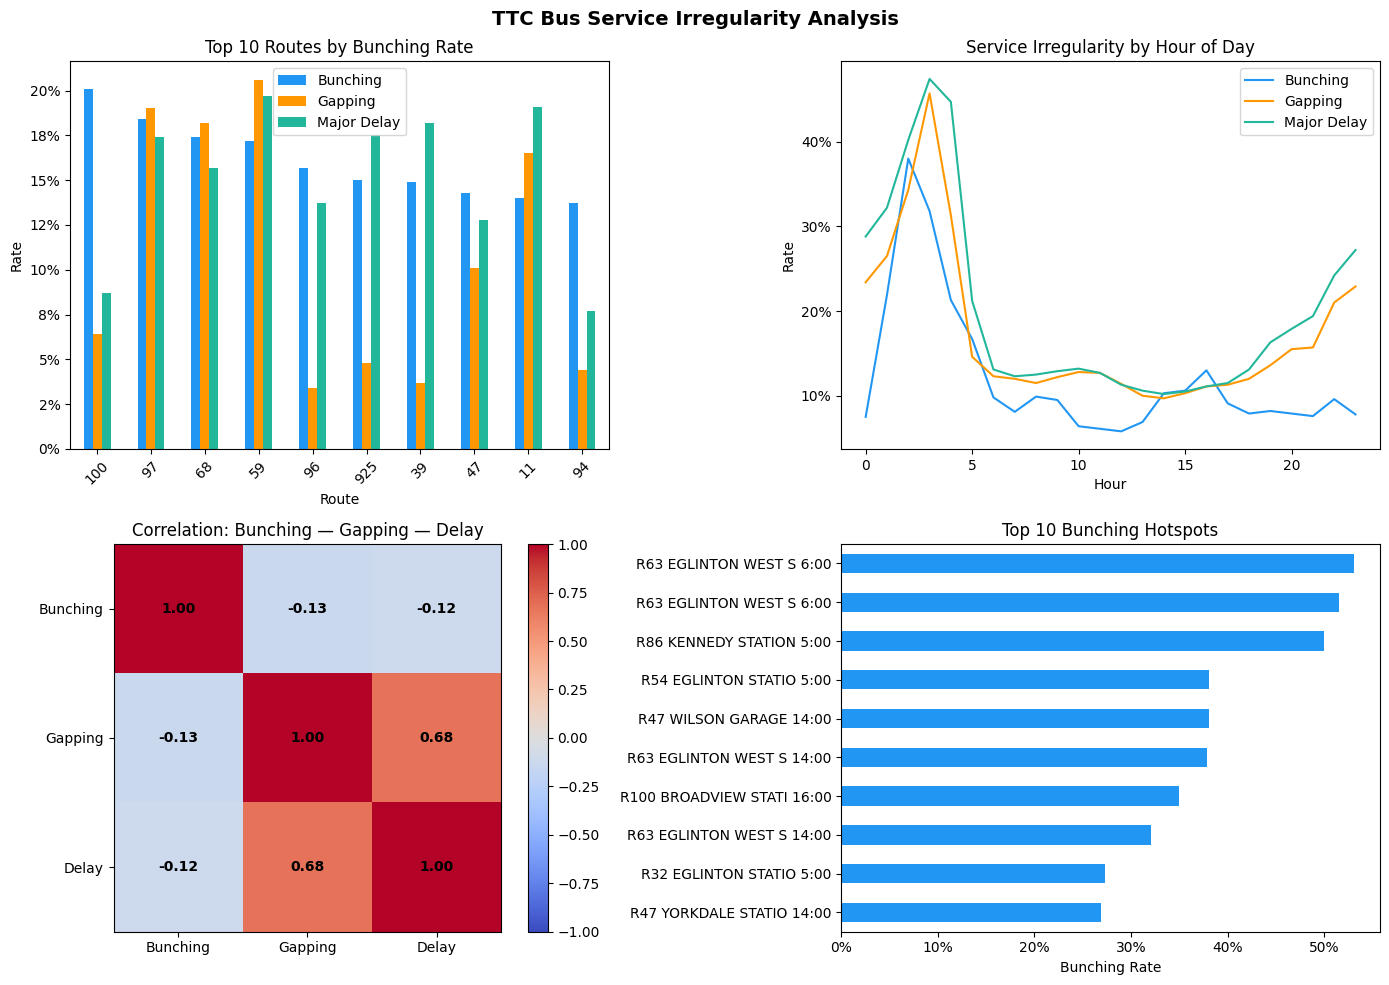

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("TTC Bus Service Irregularity Analysis", fontsize=14, fontweight="bold")

# Plot 1: Top 10 routes by bunching rate
plot1_data = route_metrics.head(10).set_index("route")
plot1_data[["bunching_rate", "gapping_rate", "major_delay_rate"]].plot(kind="bar", ax=axes[0, 0], color=["#2196F3", "#FF9800", "#22b79a"])
axes[0, 0].set_title("Top 10 Routes by Bunching Rate")
axes[0, 0].set_ylabel("Rate")
axes[0, 0].set_xlabel("Route")
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend(["Bunching", "Gapping", "Major Delay"])

# Plot 2: Bunching patterns by hour of day
plot2_data = time_metrics.sort_values("hour").set_index("hour")
plot2_data[["bunching_rate", "gapping_rate", "major_delay_rate"]].plot(ax=axes[0, 1], color=["#2196F3", "#FF9800", "#22b79a"])
axes[0, 1].set_title("Service Irregularity by Hour of Day")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Rate")
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0, 1].legend(["Bunching", "Gapping", "Major Delay"])

# Plot 3: Correlation heatmap
corr_data = bus_df_clean[["is_bunching_operational", "is_gapped_operational", "is_major_delay"]].corr()
im = axes[1, 0].imshow(corr_data, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 0].set_title("Correlation: Bunching — Gapping — Delay")
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_xticklabels(["Bunching", "Gapping", "Delay"])
axes[1, 0].set_yticks([0, 1, 2])
axes[1, 0].set_yticklabels(["Bunching", "Gapping", "Delay"])

for i in range(len(corr_data)):
    for j in range(len(corr_data.columns)):
        axes[1, 0].text(
            j, i, f"{corr_data.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=10, fontweight="bold")
plt.colorbar(im, ax=axes[1, 0])

# Plot 4: Top 10 bunching hotspots
hotspot_top = hotspot_metrics.head(10).copy()
hotspot_top["label"] = ("R" + hotspot_top["route"].astype(str) + " " + hotspot_top["location"].astype(str).str[:15] + " " +
    hotspot_top["hour"].fillna(0).astype(int).astype(str) + ":00")
hotspot_top.sort_values("bunching_rate").plot(y="bunching_rate", x="label", kind="barh", ax=axes[1, 1], legend=False, color="#2196F3")
axes[1, 1].set_title("Top 10 Bunching Hotspots")
axes[1, 1].set_xlabel("Bunching Rate")
axes[1, 1].set_ylabel("")
axes[1, 1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

#### PREPARE FINAL ML DATASET

In [30]:
# day_of_week exists
if "day_of_week" not in bus_df_clean.columns:
    bus_df_clean["day_of_week"] = bus_df_clean["datetime"].dt.dayofweek

# FEATURES
# Weather, time, route identity, incident type, direction
base_features = ["route", "year", "month", "hour", "day_of_week", "is_weekend", "is_rush_hour",
    "temp_celsius", "humidity_pct", "precipitation_mm", "wind_speed_kmh", "visibility_km",
    "is_rainy", "is_heavy_rain", "is_cold", "is_hot", "low_visibility", "high_wind", "weather_intensity",]

# Keep only columns that exist in the dataset
X_clean = bus_df_clean[[c for c in base_features if c in bus_df_clean.columns]].copy()

# Add location_id to features
X_clean["location_id"] = bus_df_clean["location_id"].values

# One-hot encode incident type and direction
incident_dummies = pd.get_dummies(bus_df_clean["incident_category"], prefix="incident", dtype=int)
direction_dummies = pd.get_dummies(bus_df_clean["direction"], prefix="dir", dtype=int)
X_clean = pd.concat([X_clean, incident_dummies, direction_dummies], axis=1)

# TARGETS
targets = pd.DataFrame({"is_major_delay": bus_df_clean["is_major_delay"], "is_gapped_operational": bus_df_clean["is_gapped_operational"],
    "is_bunching_operational": bus_df_clean["is_bunching_operational"],})

# Combine features and targets
ml_dataset_clean = pd.concat([X_clean, targets], axis=1)

# MISSING VALUE CHECK
missing = X_clean.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("WARNING: Missing values in features:")
    print(missing)
else:
    print("CLEAN: No missing values in feature matrix")

# LEAKAGE CHECK
# Variables derived from min_gap or min_delay must not appear
feature_cols = [c for c in ml_dataset_clean.columns
                if c not in targets.columns and c not in ["location", "datetime"]]

leaky_terms = ["min_gap", "min_delay", "prev_gap", "lag_", "rolling_", "gap_ratio", "route_median", "disruption"]

problematic = [col for col in feature_cols
               if any(x in col.lower() for x in leaky_terms)]

if problematic:
    print(f"WARNING: Potential leakage — remove these features: {problematic}")
else:
    print("CLEAN: No data leakage detected")

ml_dataset_clean.to_csv(OUTPUT_DIR / "ml_dataset_ready.csv", index=False)
print(f"Features used : {feature_cols}")

CLEAN: No missing values in feature matrix
CLEAN: No data leakage detected
Features used : ['route', 'year', 'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'temp_celsius', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmh', 'visibility_km', 'is_rainy', 'is_heavy_rain', 'is_cold', 'is_hot', 'low_visibility', 'high_wind', 'weather_intensity', 'location_id', 'incident_Cleaning / Sanitation', 'incident_Collision / Accident', 'incident_Diversion / Routing', 'incident_Emergency Services', 'incident_Fare / Administrative', 'incident_Investigation / Held', 'incident_Mechanical / Vehicle Failure', 'incident_Medical / Passenger Health', 'incident_Operations / Scheduling', 'incident_Other', 'incident_Road / Infrastructure Issue', 'incident_Security / Police', 'incident_Staffing / Operator Issue', 'incident_Vision / Visibility', 'incident_Weather Related', 'dir_E', 'dir_N', 'dir_S', 'dir_UNKNOWN', 'dir_W']


<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">

##### Note:
min_gap and prev_gap were intentionally excluded because the gapping and bunching targets are derived directly from headway measurements.
Including these variables would introduce data leakage: the model would be using components of the target to predict the target itself, creating circular logic and invalidating the predictive framework.
</div>

##### FEATURE CORRELATION ANALYSIS

Total ML features: 19


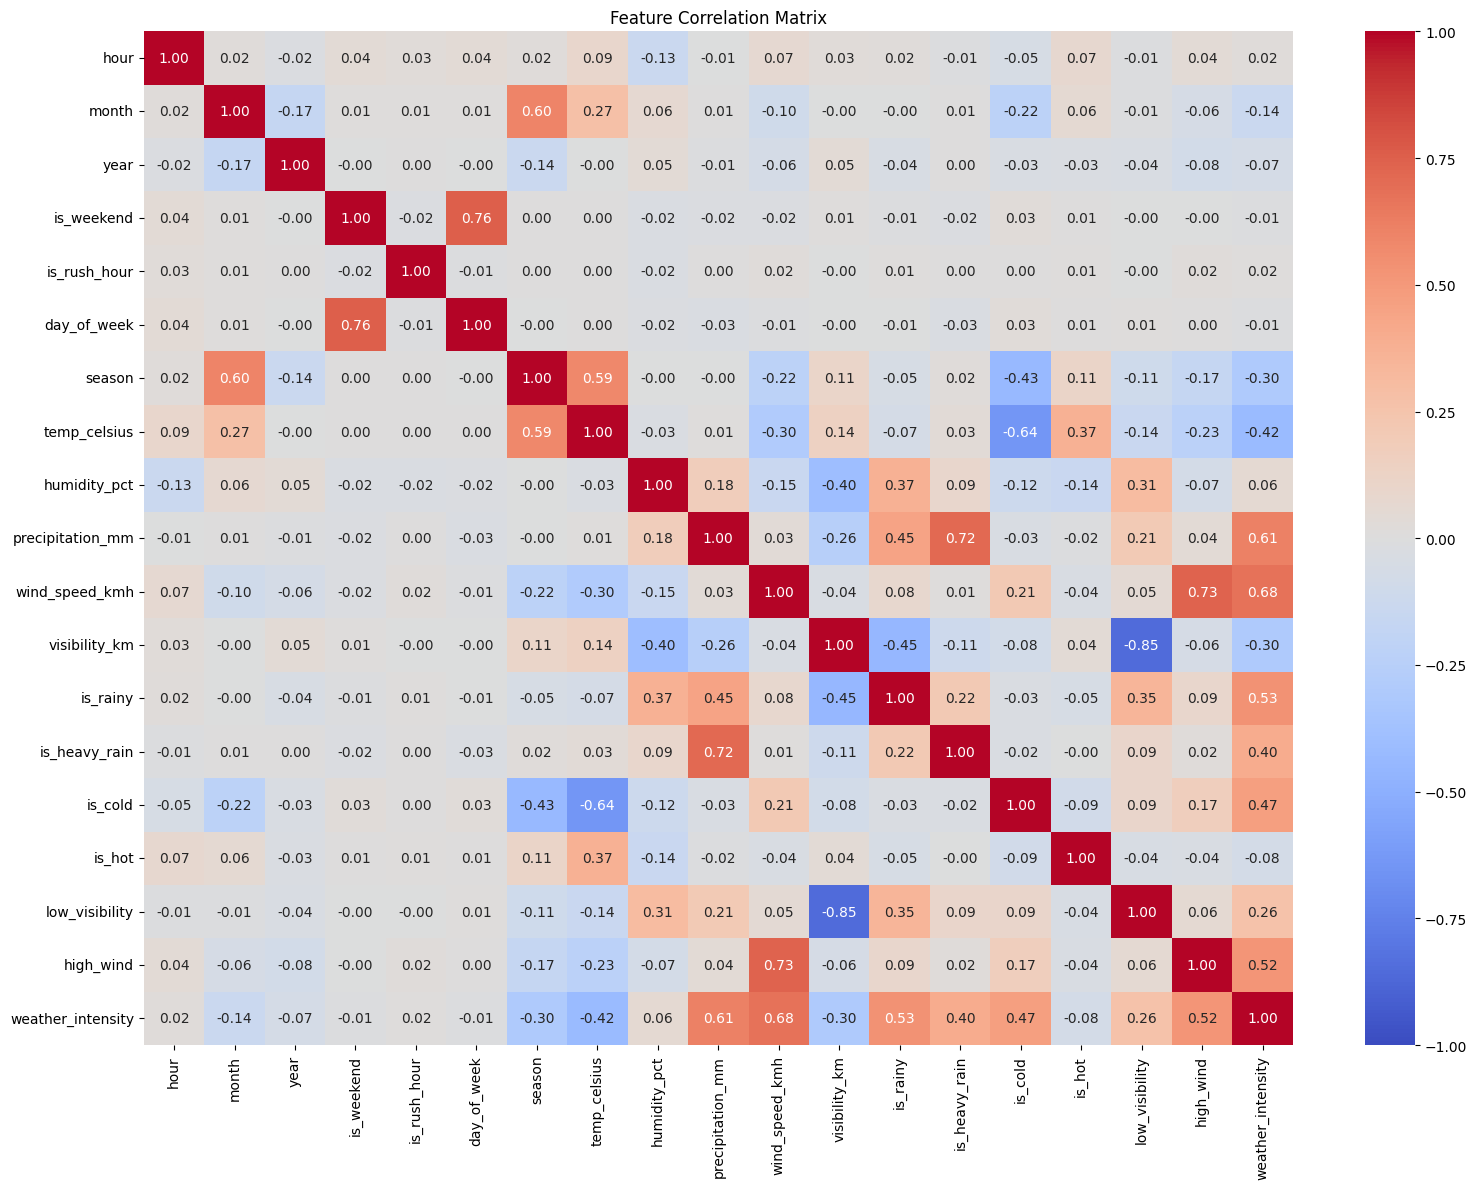


High Correlation Pairs (|r| ≥ 0.70)
          Feature 1       Feature 2  Correlation
3     visibility_km  low_visibility    -0.853900
0        is_weekend     day_of_week     0.755928
2    wind_speed_kmh       high_wind     0.734764
1  precipitation_mm   is_heavy_rain     0.715944

Top correlations with is_major_delay
is_rush_hour     -0.058521
is_weekend        0.047865
day_of_week       0.040806
hour             -0.037397
humidity_pct      0.028002
is_hot           -0.023325
wind_speed_kmh   -0.021702
year              0.018519
temp_celsius     -0.017564
high_wind        -0.014438
Name: is_major_delay, dtype: float64

Top correlations with is_gapped_operational
is_rush_hour     -0.040338
is_weekend        0.027763
hour             -0.027408
year              0.026049
day_of_week       0.022822
humidity_pct      0.021576
is_hot           -0.018003
wind_speed_kmh   -0.016384
temp_celsius     -0.015625
high_wind        -0.011027
Name: is_gapped_operational, dtype: float64

Top correlati

In [40]:
# Columns NOT used for feature correlation
exclude = [
    # Targets
    "is_major_delay",
    "is_gapped_operational",
    "is_bunching_operational",
    "is_ontime", "is_bunching_statistical", "is_gapped_statistical",
    # Leakage variables
    "min_delay",
    "min_gap",
    "gap_ratio",
    # metadata
    "date",
    "time",
    "datetime",
    "hour_dt",
    "location",
    "location_id",
    "incident",
    "incident_raw",
    "day",
    "route",
]

# Remove unnamed Excel columns
bus_df_clean = bus_df_clean.loc[:, ~bus_df_clean.columns.str.contains("^Unnamed")]
# Numeric ML features only
features = [
    c for c in bus_df_clean.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(bus_df_clean[c])]

print(f"Total ML features: {len(features)}")

# Correlation matrix
corr = bus_df_clean[features].corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# High correlation pairs
pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i,j]
        if abs(r) >= 0.70:
            pairs.append([
                corr.columns[i],
                corr.columns[j],
                r])

pairs = pd.DataFrame(pairs, columns=["Feature 1","Feature 2","Correlation"]).sort_values("Correlation", key=abs, ascending=False)
print("\nHigh Correlation Pairs (|r| ≥ 0.70)")
print(pairs if len(pairs) else "None")

# Correlation with each target
targets = ["is_major_delay", "is_gapped_operational", "is_bunching_operational"]

for target in targets:
    print(f"\nTop correlations with {target}")
    ranking = (bus_df_clean[features + [target]].corr()[target].drop(target).sort_values(key=abs, ascending=False).head(10))
    print(ranking)

# Summary
critical = (pairs["Correlation"].abs() >= 0.90).sum()
high = ((pairs["Correlation"].abs() >= 0.70) & (pairs["Correlation"].abs() < 0.90)).sum()

print("\nMULTICOLLINEARITY SUMMARY")
print(f"Critical pairs (>0.90): {critical}")
print(f"High pairs (0.70-0.90): {high}")

if critical == 0:
    print("\nNo serious multicollinearity detected.")

<div style="background-color:#d2f0c5; font-size:12.5px; padding:5px">
    
##### Feature Correlation Analysis<br>

Before training the model, we checked whether any features were too similar to each other (multicollinearity), which can confuse some models.

No serious overlap was detected. Four feature pairs showed moderate correlation, but all four were expected — each pair is simply a continuous measurement alongside a yes/no version of the same condition (for example, actual wind speed alongside a "high wind" flag). These are not duplicates, they capture different aspects of the same condition.

<b>We kept all features:</b> The models we are using (Random Forest and XGBoost) handle moderate correlation well and actually benefit from having both the continuous and binary versions of each feature available. Removing them would lose information without improving model performance.

<b>Target correlations:</b> No single feature strongly predicts delay, gapping, or bunching on its own. The strongest individual correlation was only 0.06 — essentially weak. This is expected. Service disruptions are not caused by one thing alone, they result from combinations of route, time of day, weather, and incident type working together.

<b>Final decision:</b> All features were kept. Tree-based ensemble models were selected because they are specifically designed to detect these kinds of combined, non-linear patterns that simple linear models would miss.
</div>

or to drop this, duplicate information pairs:
drop_cols = [
    "low_visibility",
    "high_wind",
    "is_heavy_rain",
    "is_weekend"
]

What do you think?